# Анализ сайта «СберАвтоподписка»

Цель проекта — построить модель, которая по данным о визите пользователя на сайт предсказывает вероятность совершения целевого действия: заявки, заказа звонка, открытия диалога и других важных действий.

Результаты модели могут быть использованы для:
- оценки качества рекламных каналов;
- оптимизации маркетинговых кампаний;
- анализа факторов, влияющих на конверсию.

## Описание данных

В работе используются два набора данных:

`ga_sessions` — данные о визитах пользователей на сайт. Одна строка соответствует одному визиту.

`ga_hits_agg` — агрегированные данные по действиям пользователей внутри визита. На их основе была сформирована целевая переменная `target`.

Целевая переменная:
- `1` — в рамках визита было совершено целевое действие;
- `0` — целевого действия не было.

In [1]:
# Импортируем библиотеки
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV

import joblib

In [3]:
sessions = pd.read_csv('../ga_sessions.csv')
hits_agg = pd.read_csv('../ga_hits_agg.csv')

C:\Users\admin\AppData\Local\Temp\ipykernel_22852\2629871673.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  sessions = pd.read_csv('../ga_sessions.csv')


In [4]:
sessions.head()

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
0,9055434745589932991.1637753792.1637753792,2108382700.163776,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust
1,905544597018549464.1636867290.1636867290,210838531.163687,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow
2,9055446045651783499.1640648526.1640648526,2108385331.164065,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk
3,9055447046360770272.1622255328.1622255328,2108385564.162225,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow
4,9055447046360770272.1622255345.1622255345,2108385564.162225,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow


In [5]:
hits_agg.head()

,session_id,target,hits_count,max_hit_number,unique_pages,unique_events
0,1000009318903347362.1632663668.1632663668,0,10,15,3,6
1,1000010177899156286.1635013443.1635013443,0,6,12,2,5
2,1000013386240115915.1635402956.1635402956,0,11,17,3,6
3,1000017303238376207.1623489300.1623489300,0,12,18,3,8
4,1000020580299877109.1624943350.1624943350,0,1,3,1,1


In [6]:
print('Размер ga_sessions:', sessions.shape)
print('Размер ga_hits_agg:', hits_agg.shape)

Размер ga_sessions: (1860042, 18)
Размер ga_hits_agg: (1734610, 6)


Датасет **ga_sessions.csv** содержит информацию о визитах пользователей на сайт: источник трафика, устройство, географию и другие параметры сессии.

Исходный файл **ga_hits.csv** содержал данные обо всех действиях пользователей внутри визитов и занимал значительный объём памяти. Поэтому для работы был подготовлен агрегированный датасет **ga_hits_agg.csv**, содержащий:
- количество действий внутри сессии;
- число уникальных страниц;
- число уникальных событий;
- целевую переменную *target*.

## Объединение и первичная обработка данных

In [7]:
df = sessions.merge(
    hits_agg,
    on='session_id',
    how='left'
)

df['target'] = df['target'].fillna(0).astype(int)

df.shape

(1860042, 23)

In [8]:
df.head()

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,...,device_model,device_screen_resolution,device_browser,geo_country,geo_city,target,hits_count,max_hit_number,unique_pages,unique_events
0,9055434745589932991.1637753792.1637753792,2108382700.163776,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,...,NaN,360x720,Chrome,Russia,Zlatoust,0,2.0,4.0,1.0,2.0
1,905544597018549464.1636867290.1636867290,210838531.163687,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,...,NaN,385x854,Samsung Internet,Russia,Moscow,0,1.0,3.0,1.0,1.0
2,9055446045651783499.1640648526.1640648526,2108385331.164065,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,...,NaN,360x720,Chrome,Russia,Krasnoyarsk,0,16.0,20.0,2.0,3.0
3,9055447046360770272.1622255328.1622255328,2108385564.162225,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,...,NaN,393x786,Chrome,Russia,Moscow,0,3.0,7.0,1.0,2.0
4,9055447046360770272.1622255345.1622255345,2108385564.162225,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,...,NaN,393x786,Chrome,Russia,Moscow,0,2.0,3.0,1.0,2.0


In [9]:
df.isna().mean().sort_values(ascending=False).head(10)

device_model      0.991216
utm_keyword       0.581740
device_os         0.575330
device_brand      0.197403
utm_adcontent     0.180434
utm_campaign      0.118063
unique_pages      0.068695
max_hit_number    0.068695
hits_count        0.068695
unique_events     0.068695
dtype: float64

После объединения датасетов были обнаружены пропуски в некоторых признаках.

Наибольшее количество пропусков наблюдается в признаках: **'device_model'**, **'utm_keyword'** и **'device_os'**.

## Обработка данных

In [10]:
print('Количество дубликатов:', df.duplicated().sum())

Количество дубликатов: 0


In [11]:
#Удалим признак 'device_model', т.к. он почти поностью состоит из пропусков
drop_cols = ['device_model']

df = df.drop(columns=drop_cols)

In [12]:
# Заполним пропуски в категориальных признаках
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna('unknown')

In [13]:
# Заполним пропуски в числовых признаках
num_cols = [
    'hits_count',
    'max_hit_number',
    'unique_pages',
    'unique_events'
]

for col in num_cols:
    df[col] = df[col].fillna(0)

In [14]:
# Обработка временных признаков
df['visit_date'] = pd.to_datetime(df['visit_date'])
df['visit_month'] = df['visit_date'].dt.month
df['visit_day'] = df['visit_date'].dt.day
df['visit_weekday'] = df['visit_date'].dt.weekday

df['visit_hour'] = pd.to_datetime(
    df['visit_time'],
    format='%H:%M:%S'
).dt.hour

In [15]:
df.isna().sum().sort_values(ascending=False).head(10)

session_id       0
client_id        0
visit_date       0
visit_time       0
visit_number     0
utm_source       0
utm_medium       0
utm_campaign     0
utm_adcontent    0
utm_keyword      0
dtype: int64

На этапе подготовки данных были удалены признаки с большим количеством пропусков, обработаны пропущенные значения;

Созданы дополнительные временные признаки:

    - месяц визита;

    - день месяца;

    - день недели;
    
    - час визита.

Подготовленные данные можно использовать для дальнейшего анализа и построения модели.

## Разведочный анализ данных (EDA)

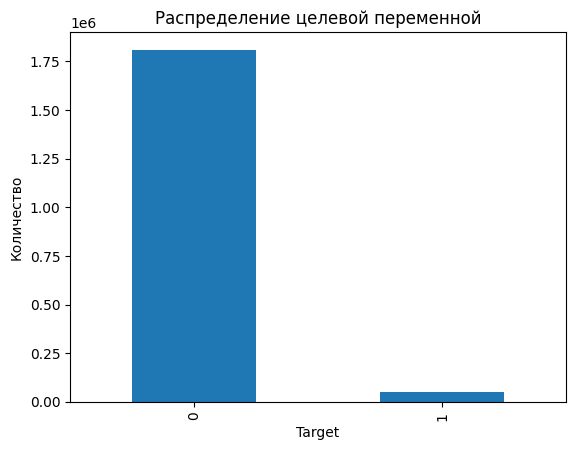

In [16]:
# Анализ целевой переменной
df['target'].value_counts(normalize=True)

df['target'].value_counts().plot(kind='bar')

plt.title('Распределение целевой переменной')
plt.xlabel('Target')
plt.ylabel('Количество')

plt.show()

В данных наблюдается сильный дисбаланс классов. Целевое действие совершается относительно редко — только небольшой процент пользователей выполняет конверсионное действие. Поэтому в качестве основной метрики качества модели была выбрана ROC-AUC.

### Конверсия по типу устройства

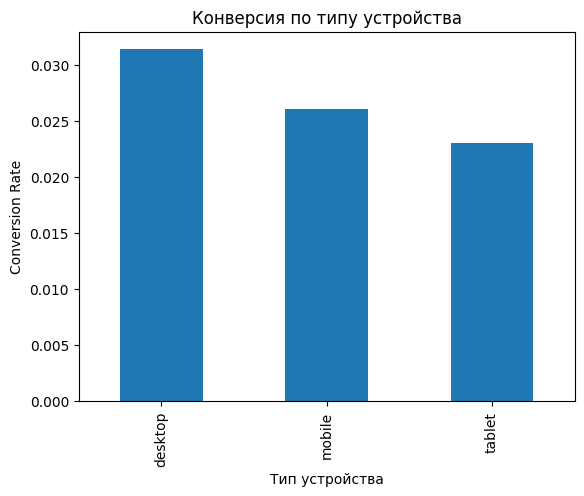

In [17]:
device_cr = (
    df.groupby('device_category')['target']
    .mean()
    .sort_values(ascending=False)
)

device_cr.plot(kind='bar')

plt.title('Конверсия по типу устройства')
plt.xlabel('Тип устройства')
plt.ylabel('Conversion Rate')

plt.show()


По графику можно сделать вывод, что, вероятно, с компьютера проще оформлять подписку.

### Конверсия по источнику трафика

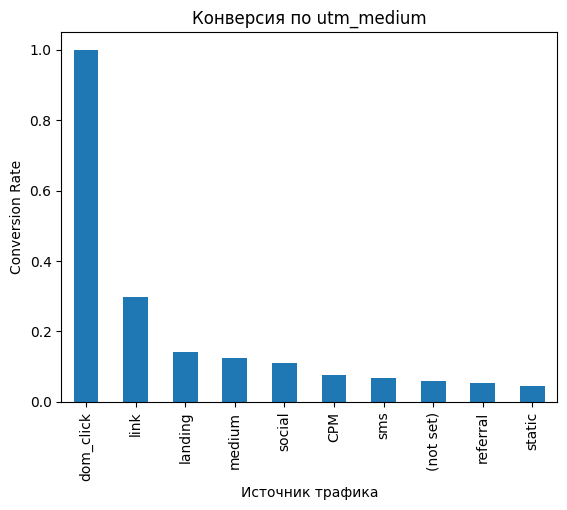

In [18]:
utm_cr = (
    df.groupby('utm_medium')['target']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
utm_cr.plot(kind='bar')

plt.title('Конверсия по utm_medium')
plt.xlabel('Источник трафика')
plt.ylabel('Conversion Rate')

plt.show()

In [19]:
df[df['utm_medium'] == 'dom_click'].shape[0]

1

Некоторые каналы показывают очень высокую конверсию, однако количество наблюдений для них может быть небольшим.

Например, **dom_click** имеет высокий уровень конверсии, но встречается значительно реже по сравнению с основными источниками трафика. Поэтому подобные значения необходимо интерпретировать с осторожностью.

Рассмотрим 'Conversion Rate' для наиболее популярных каналов.

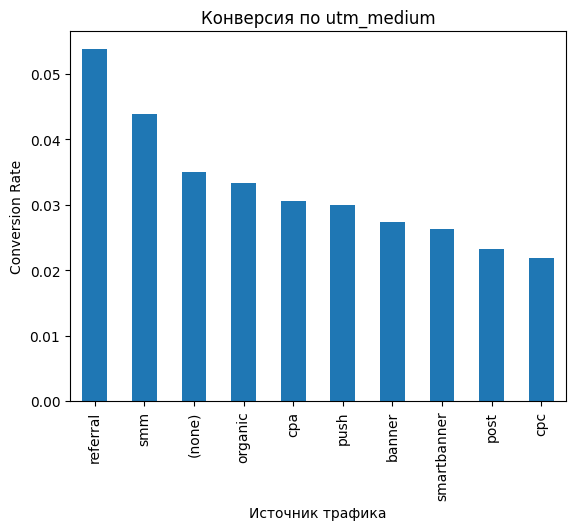

In [20]:
utm_stats = (
    df.groupby('utm_medium')
    .agg(
        conversion=('target', 'mean'),
        count=('target', 'size')
    )
)

utm_stats = utm_stats[utm_stats['count'] > 1000]

utm_stats = utm_stats.sort_values(
    by='conversion',
    ascending=False
).head(10)

utm_stats

utm_stats['conversion'].plot(kind='bar')

plt.title('Конверсия по utm_medium')
plt.xlabel('Источник трафика')
plt.ylabel('Conversion Rate')

plt.show()

### Активность пользователей и конверсия в зависимости от времени

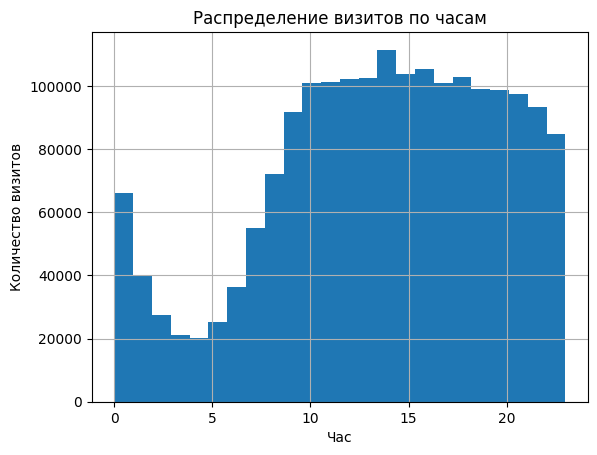

In [21]:
df['visit_hour'].hist(bins=24)

plt.title('Распределение визитов по часам')
plt.xlabel('Час')
plt.ylabel('Количество визитов')

plt.show()

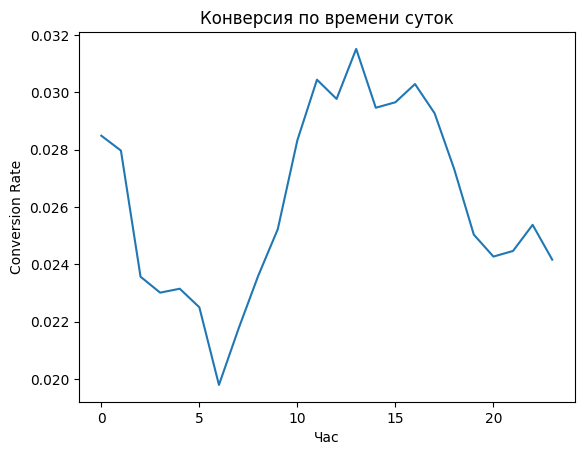

In [22]:
hour_cr = (
    df.groupby('visit_hour')['target']
    .mean()
)

hour_cr.plot()

plt.title('Конверсия по времени суток')
plt.xlabel('Час')
plt.ylabel('Conversion Rate')

plt.show()

По распределению видно, что наибольшая активность пользователей наблюдается в дневное и вечернее время.

При этом вероятность совершения целевого действия выше преимущественно в дневные часы.

### Анализ числовых признаков

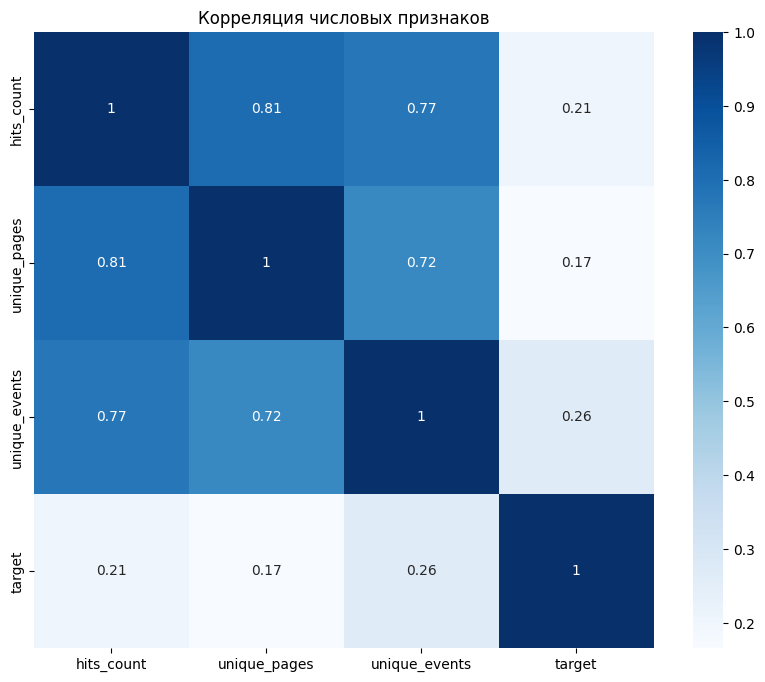

In [23]:
#Корреляции числовых признаков
corr = df[[
    'hits_count',
    'unique_pages',
    'unique_events',
    'target'
]].corr()
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap='Blues'
)

plt.title('Корреляция числовых признаков')
plt.show()

### Важное замечание

Мы видим сильную корреляцию признаков 'hits_count', 'unique_pages' и 'unique_events' с целевой переменной. При первом обучении модели с использованием этих признаков, модель показывала слишком высокий ROC-AUC. Использование этих признаков может привести к утечке целевой переменной, т.к. эти признаки напрямую с ней связаны и формируются в процессе сессии.

### Анализ повторных визитов

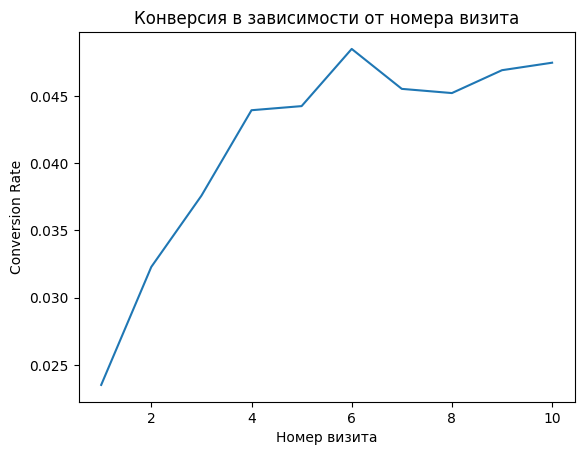

In [24]:
visit_cr = (
    df.groupby('visit_number')['target']
    .mean()
    .head(10)
)

visit_cr.plot()

plt.title('Конверсия в зависимости от номера визита')
plt.xlabel('Номер визита')
plt.ylabel('Conversion Rate')

plt.show()

Пользователи, которые возвращаются на сайт повторно, чаще совершают целевое действие. Это может говорить о том, что решение об оформлении подписки принимается не сразу и требует нескольких посещений сайта.

### Поведенческие признаки и целевое действие

<Figure size 1000x500 with 0 Axes>

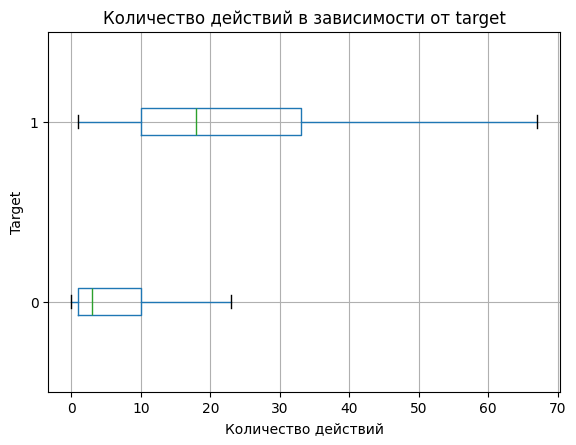

In [25]:
plt.figure(figsize=(10, 5))

df.boxplot(
    column='hits_count',
    by='target',
    vert=False,
    showfliers=False
)

plt.title('Количество действий в зависимости от target')
plt.suptitle('')

plt.xlabel('Количество действий')
plt.ylabel('Target')

plt.show()

Пользователи, совершившие целевое действие проводят больше действий (hits_count)

### Подготовка данных для обучения модели с учетом EDA

In [26]:
#Удаление технических признаков
drop_cols = [
    'session_id',
    'client_id',
    'visit_date',
    'visit_time',
    'hits_count',
    'max_hit_number',
    'unique_pages',
    'unique_events'
]

model_df = df.drop(columns=drop_cols)

In [27]:
# Разбиение на обучающую и тестовые выборки

X = model_df.drop('target', axis=1)
y = model_df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [28]:
#Кодирование категориальных признаков
cat_cols = X.select_dtypes(include='object').columns

encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

X_train_enc = X_train.copy()
X_test_enc = X_test.copy()

X_train_enc[cat_cols] = encoder.fit_transform(
    X_train[cat_cols]
)

X_test_enc[cat_cols] = encoder.transform(
    X_test[cat_cols]
)

## Обучение моделей

### Baseline модель - Logistic Regression

In [29]:
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    solver='lbfgs'
)

lr_model.fit(X_train_enc, y_train)

lr_pred = lr_model.predict_proba(X_test_enc)[:, 1]
lr_auc = roc_auc_score(y_test, lr_pred)

print(f'Logistic Regression ROC-AUC: {lr_auc:.3f}')

Logistic Regression ROC-AUC: 0.606


c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


В качестве baseline-модели использовалась Логистическая регрессия.
Модель показала ROC-AUC = 0.606

### Random Forest

In [30]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf_model.fit(X_train_enc, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
rf_pred = rf_model.predict_proba(X_test_enc)[:, 1]

rf_auc = roc_auc_score(y_test, rf_pred)

print(f'Random Forest ROC-AUC: {rf_auc:.3f}')

Random Forest ROC-AUC: 0.703


Random Forest показывает более высокое качество (ROC-AUC = 0.703) по сравнению с логистической регрессией благодаря способности учитывать нелинейные зависимости между признаками.

### LightGBM

In [32]:
lgbm_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    verbose=-1
)

lgbm_model.fit(X_train_enc, y_train)


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.1
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [33]:
lgbm_pred = lgbm_model.predict_proba(X_test_enc)[:, 1]
lgbm_auc = roc_auc_score(y_test, lgbm_pred)

print(f'LightGBM ROC-AUC: {lgbm_auc:.3f}')

LightGBM ROC-AUC: 0.713


LightGBM - лучшая на данный момент модель за счет ROC-AUC = 0.713 и скорости обучения.

### CatBoost

In [34]:
cat_features = X.select_dtypes(include='object').columns.tolist()
cat_model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    loss_function='Logloss',
    eval_metric='AUC',
    verbose=False
)

cat_model.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

cat_pred = cat_model.predict_proba(X_test)[:, 1]
cat_auc = roc_auc_score(y_test, cat_pred)

print(f'CatBoost ROC-AUC: {cat_auc:.3f}')

CatBoost ROC-AUC: 0.710


### Сравнение моделей

In [35]:
models_compare = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'LightGBM',
        'CatBoost'
    ],
    'ROC-AUC': [
        lr_auc,
        rf_auc,
        lgbm_auc,
        cat_auc
    ]
})

models_compare = models_compare.sort_values(
    by='ROC-AUC',
    ascending=False
)

models_compare

,Model,ROC-AUC
2,LightGBM,0.713376
3,CatBoost,0.710167
1,Random Forest,0.702722
0,Logistic Regression,0.606499


### Вывод

Лучшее качество показали модели градиентного бустинга — LightGBM. Оптимальная модель для нашей задачи - за счет наибольшего ROC-AUC. Она также быстро обучается потребляет меньше оперативной памяти.

### ROC Curve и Confusion Matrix

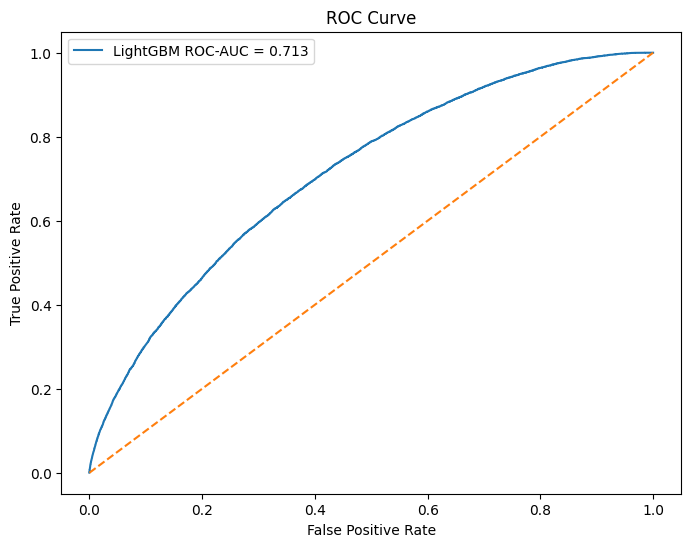

In [36]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    lgbm_pred
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f'LightGBM ROC-AUC = {lgbm_auc:.3f}'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve')

plt.legend()

plt.show()

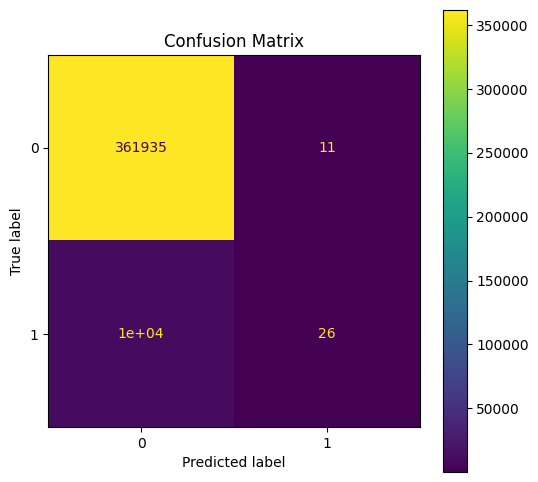

In [37]:
lgbm_class_pred = (
    lgbm_pred >= 0.5
).astype(int)

cm = confusion_matrix(
    y_test,
    lgbm_class_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)
fig, ax = plt.subplots(figsize=(6, 6))

disp.plot(ax=ax)
plt.title('Confusion Matrix')

plt.show()

Модель очень хорошо определяет класс 0, но хуже распознаёт положительный класс. Это связано с изначально несбалансироваными данными.

### Важность признаков

In [38]:
feature_importance = pd.DataFrame({
    'feature': X_train_enc.columns,
    'importance': lgbm_model.feature_importances_
})
feature_importance = feature_importance.sort_values(
    by='importance',
    ascending=False
)
feature_importance.head(15)

,feature,importance
9,device_screen_resolution,768
12,geo_city,559
3,utm_campaign,525
0,visit_number,524
14,visit_day,481
1,utm_source,465
16,visit_hour,456
13,visit_month,339
2,utm_medium,303
5,utm_keyword,275


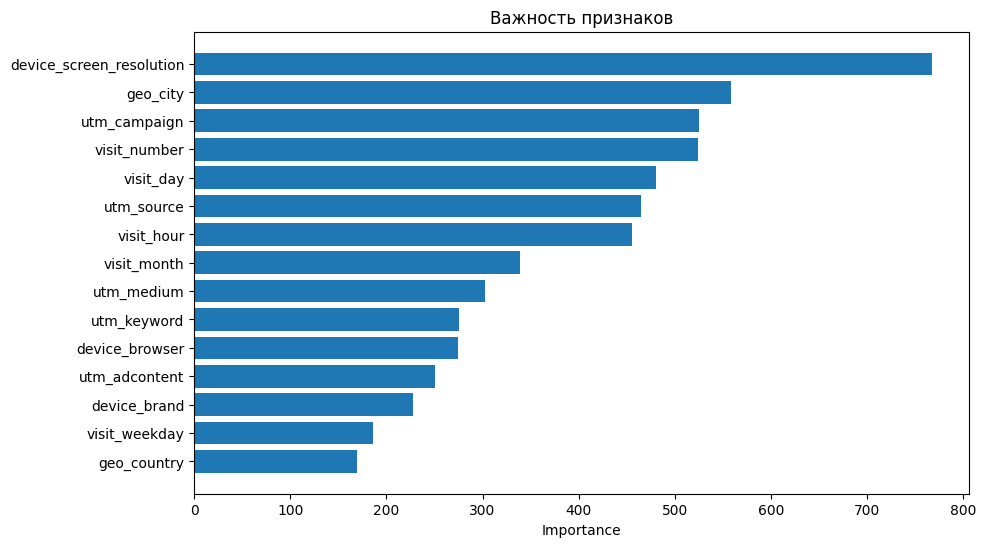

In [39]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features['feature'],
    top_features['importance']
)
plt.gca().invert_yaxis()
plt.title('Важность признаков')
plt.xlabel('Importance')
plt.show()

Наиболее важными признаками для модели оказались:

- разрешение экрана устройства;

- город пользователя;

- рекламная кампания;

Вероятно, разрешение устройства влияет на особенности интерфейса, что может отражаться на вероятности совершения целевого действия. Также можно предположить, что повторные визиты и характеристики рекламного трафика оказывают существенное влияние на конверсию пользователей.

### Подбор гиперпараметров для LightGBM

In [40]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [4, 6, 8],
    'num_leaves': [31, 50, 70]
}

lgbm_base = LGBMClassifier(
    random_state=42,
    verbose=-1
)

search = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=param_grid,
    n_iter=8,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train_enc, y_train)

print('Лучшие параметры:', search.best_params_)
print('Лучший ROC-AUC на CV:', search.best_score_)

Лучшие параметры: {'num_leaves': 70, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1}
Лучший ROC-AUC на CV: 0.7125688940554943


In [41]:
best_lgbm_model = search.best_estimator_

best_lgbm_pred = best_lgbm_model.predict_proba(X_test_enc)[:, 1]
best_lgbm_auc = roc_auc_score(y_test, best_lgbm_pred)

print(f'Tuned LightGBM ROC-AUC: {best_lgbm_auc:.3f}')

Tuned LightGBM ROC-AUC: 0.717


После подбора гиперпараметров качество модели удалось немного улучшить. Лучший результат показала модель LightGBM со следующими параметрами: max_depth = 6, n_estimators = 300, num_leaves = 70, learning_rate = 0.1

### Повторная оценка важности признаков

In [42]:
feature_importance_best  = pd.DataFrame({
    'feature': X_train_enc.columns,
    'importance': best_lgbm_model.feature_importances_
})
feature_importance_best  = feature_importance.sort_values(
    by='importance',
    ascending=False
)
feature_importance_best .head(15)

,feature,importance
9,device_screen_resolution,768
12,geo_city,559
3,utm_campaign,525
0,visit_number,524
14,visit_day,481
1,utm_source,465
16,visit_hour,456
13,visit_month,339
2,utm_medium,303
5,utm_keyword,275


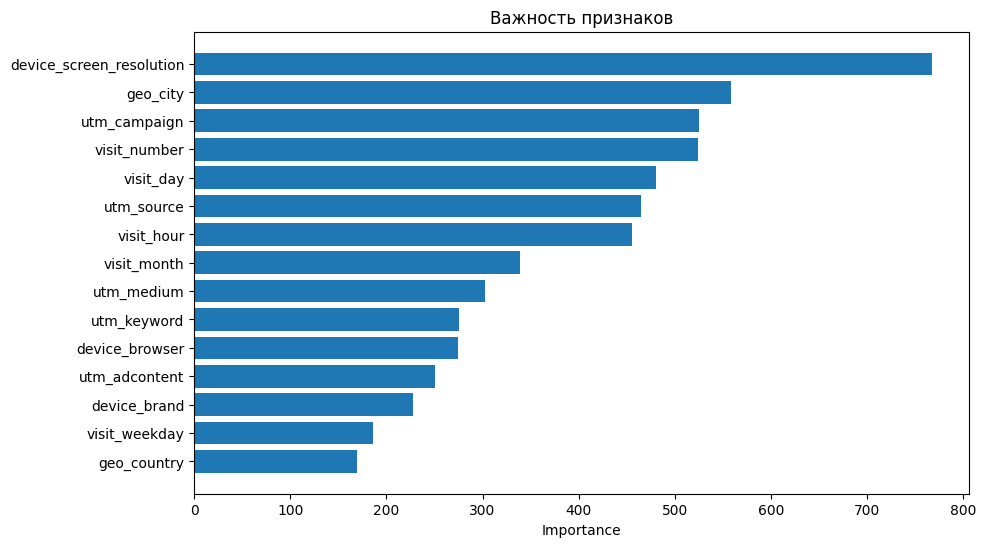

In [43]:
top_features_best = feature_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features_best ['feature'],
    top_features_best ['importance']
)
plt.gca().invert_yaxis()
plt.title('Важность признаков')
plt.xlabel('Importance')
plt.show()

После подбора гиперпараметров важность признаков немного поменялась. После **device_screen_resolution** на второе место вышел **visit_day**. **visit_hour** и **visit_month** также являются сильными признаками. Конверсия зависит от времени взаимодействия и геолокации.

## Сохранение артефактов

In [46]:
joblib.dump(best_lgbm_model, 'models/model.pkl')
joblib.dump(encoder, 'models/encoder.pkl')

['models/encoder.pkl']

Модель была упакована в FastAPI-сервис и контейнеризирована с помощью Docker.
API принимает данные визита в формате, близком к таблице ga_sessions, автоматически преобразует их в признаки модели и возвращает прогноз целевого действия.

Сервис запускается командой:

docker compose up --build

После запуска документация доступна по адресу:

http://127.0.0.1:8000/docs

## Итоговые выводы


В рамках проекта был выполнен EDA данных из датасетов `ga_hits.csv` и `ga_sessions.csv`. Были удалены технические признаки, обработаны пропуски и проведен анализ пользовательского поведения.

В ходе исследования были проанализированы:

* конверсии по типам устройств;

* источники рекламного трафика;

* временные признаки;

* поведенческие характеристики пользователей.

Также был выявлен значительный дисбаланс целевой переменной, что связано с относительно низкой вероятностью совершения целевого действия пользователем.

Для выбора наилучшей модели были обучены:

* Logistic Regression;

* Random Forest;

* CatBoost;

* LightGBM.

В качестве основной модели была выбрана LightGBM благодаря наилучшему значению ROC-AUC и высокой скорости обучения.

После подбора гиперпараметров итоговое качество модели составило:

* ROC-AUC = 0.717.

Анализ важности признаков показал, что наибольшее влияние оказывают:

* `device_screen_resolution`;

* временные признаки (`visit_day`, `visit_hour`, `visit_month`);

* геолокация пользователя;

* характеристики рекламного трафика.

Вероятно, разрешение экрана влияет на удобство взаимодействия пользователя с интерфейсом сайта. Также модель показывает, что пользователи, совершающие повторные посещения сайта, имеют более высокую вероятность совершения целевого действия.

В рамках проекта модель была упакована в FastAPI-сервис и контейнеризирована с помощью Docker.

Полученная модель может использоваться для:

* оценки эффективности рекламных кампаний;

* оптимизации UX сайта;

